In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
# step_1:read the data

In [4]:
loan_data=pd.read_csv(r"C:\Users\dharm\Documents\Nareshit\data files\train_ctrUa4K.csv")

In [5]:
loan_data

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...,...
609,LP002978,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,LP002979,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,LP002983,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,LP002984,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
# step-2: data quick checks

In [6]:
loan_data.size

7982

In [7]:
loan_data.shape

(614, 13)

In [8]:
loan_data.dtypes

Loan_ID               object
Gender                object
Married               object
Dependents            object
Education             object
Self_Employed         object
ApplicantIncome        int64
CoapplicantIncome    float64
LoanAmount           float64
Loan_Amount_Term     float64
Credit_History       float64
Property_Area         object
Loan_Status           object
dtype: object

In [20]:
loan_data.describe()


,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [9]:
loan_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 614 entries, 0 to 613
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Loan_ID            614 non-null    object 
 1   Gender             601 non-null    object 
 2   Married            611 non-null    object 
 3   Dependents         599 non-null    object 
 4   Education          614 non-null    object 
 5   Self_Employed      582 non-null    object 
 6   ApplicantIncome    614 non-null    int64  
 7   CoapplicantIncome  614 non-null    float64
 8   LoanAmount         592 non-null    float64
 9   Loan_Amount_Term   600 non-null    float64
 10  Credit_History     564 non-null    float64
 11  Property_Area      614 non-null    object 
 12  Loan_Status        614 non-null    object 
dtypes: float64(4), int64(1), object(8)
memory usage: 62.5+ KB


In [ ]:
# step-3: categorizing the columns based on  categorical and numreical columns

In [10]:
cat=loan_data.select_dtypes(include="object").columns
cat                     

Index(['Loan_ID', 'Gender', 'Married', 'Dependents', 'Education',
       'Self_Employed', 'Property_Area', 'Loan_Status'],
      dtype='object')

In [54]:
num=loan_data.select_dtypes(exclude="object").columns
num

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

In [ ]:
# step-4:fill the missing values

In [12]:
loan_data.isnull().sum()

Loan_ID               0
Gender               13
Married               3
Dependents           15
Education             0
Self_Employed        32
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount           22
Loan_Amount_Term     14
Credit_History       50
Property_Area         0
Loan_Status           0
dtype: int64

In [13]:
loan_data['Gender'].mode()

0    Male
Name: Gender, dtype: object

In [14]:
loan_data['Gender']=loan_data['Gender'].fillna(loan_data['Gender'].mode()[0])

In [15]:
loan_data['Married'].mode()

0    Yes
Name: Married, dtype: object

In [16]:
loan_data['Married']=loan_data['Married'].fillna(loan_data['Married'].mode()[0])

In [17]:
loan_data['Dependents'].mode()

0    0
Name: Dependents, dtype: object

In [18]:
loan_data['Dependents']=loan_data['Dependents'].fillna(loan_data['Dependents'].mode()[0])

In [19]:
loan_data['Self_Employed'].mode()

0    No
Name: Self_Employed, dtype: object

In [20]:
loan_data['Self_Employed']=loan_data['Self_Employed'].fillna(loan_data['Self_Employed'].mode()[0])

In [21]:
loan_data['LoanAmount'].median()

128.0

In [22]:
loan_data['LoanAmount']=loan_data['LoanAmount'].fillna(loan_data['LoanAmount'].median())

In [23]:
loan_data['Loan_Amount_Term'].median()

360.0

In [24]:
loan_data['Loan_Amount_Term']=loan_data['Loan_Amount_Term'].fillna(loan_data['Loan_Amount_Term'].median())

In [25]:
loan_data['Credit_History'].median()

1.0

In [26]:
loan_data['Credit_History']=loan_data['Credit_History'].fillna(loan_data['Credit_History'].median())


In [27]:
loan_data.isnull().sum()

Loan_ID              0
Gender               0
Married              0
Dependents           0
Education            0
Self_Employed        0
ApplicantIncome      0
CoapplicantIncome    0
LoanAmount           0
Loan_Amount_Term     0
Credit_History       0
Property_Area        0
Loan_Status          0
dtype: int64

In [28]:
# alternate all cat at time
# cat_cols = ['Gender',
#             'Married',
#             'Dependents',
#             'Education',
#             'Self_Employed',
#             'Property_Area',
#             'Loan_Status']

# for col in cat_cols:
#     visa_df[col] = visa_df[col].fillna(visa_df[col].mode()[0])

In [29]:
# # alternate for numerical 
# num_cols = ['ApplicantIncome',
#             'CoapplicantIncome',
#             'LoanAmount',
#             'Loan_Amount_Term',
#             'Credit_History']

# for col in num_cols:
#     visa_df[col] = visa_df[col].fillna(visa_df[col].median())

In [30]:
 # Step-5: Categorical data analysis
 #        Unique
 #        nunique
 #        value counts
 #        bar chart
 #        count plot
 #        pie chart


In [31]:
loan_data=loan_data.drop(['Loan_ID'],axis=1)

In [33]:
loan_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106,0.0,40.0,180.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583,0.0,187.0,360.0,1.0,Urban,Y


In [ ]:
# nunique

In [45]:
loan_data.nunique()

Loan_ID              614
Gender                 2
Married                2
Dependents             4
Education              2
Self_Employed          2
ApplicantIncome      505
CoapplicantIncome    287
LoanAmount           203
Loan_Amount_Term      10
Credit_History         2
Property_Area          3
Loan_Status            2
dtype: int64

In [ ]:
# value counts

In [39]:
keys=loan_data.value_counts().keys()
#keys are names=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 
#'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'], length=614)


In [42]:
values=loan_data.value_counts().values


In [44]:
cat=loan_data.select_dtypes(include="object").columns.tolist()
cat

['Gender',
 'Married',
 'Dependents',
 'Education',
 'Self_Employed',
 'Property_Area',
 'Loan_Status']

In [45]:
for col in cat: 
    print("\n", col)
    print(loan_data[col].value_counts())


 Gender
Gender
Male      502
Female    112
Name: count, dtype: int64

 Married
Married
Yes    401
No     213
Name: count, dtype: int64

 Dependents
Dependents
0     360
1     102
2     101
3+     51
Name: count, dtype: int64

 Education
Education
Graduate        480
Not Graduate    134
Name: count, dtype: int64

 Self_Employed
Self_Employed
No     532
Yes     82
Name: count, dtype: int64

 Property_Area
Property_Area
Semiurban    233
Urban        202
Rural        179
Name: count, dtype: int64

 Loan_Status
Loan_Status
Y    422
N    192
Name: count, dtype: int64


In [46]:
loan_data.columns

Index(['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed',
       'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status'],
      dtype='object')

<function matplotlib.pyplot.show(close=None, block=None)>

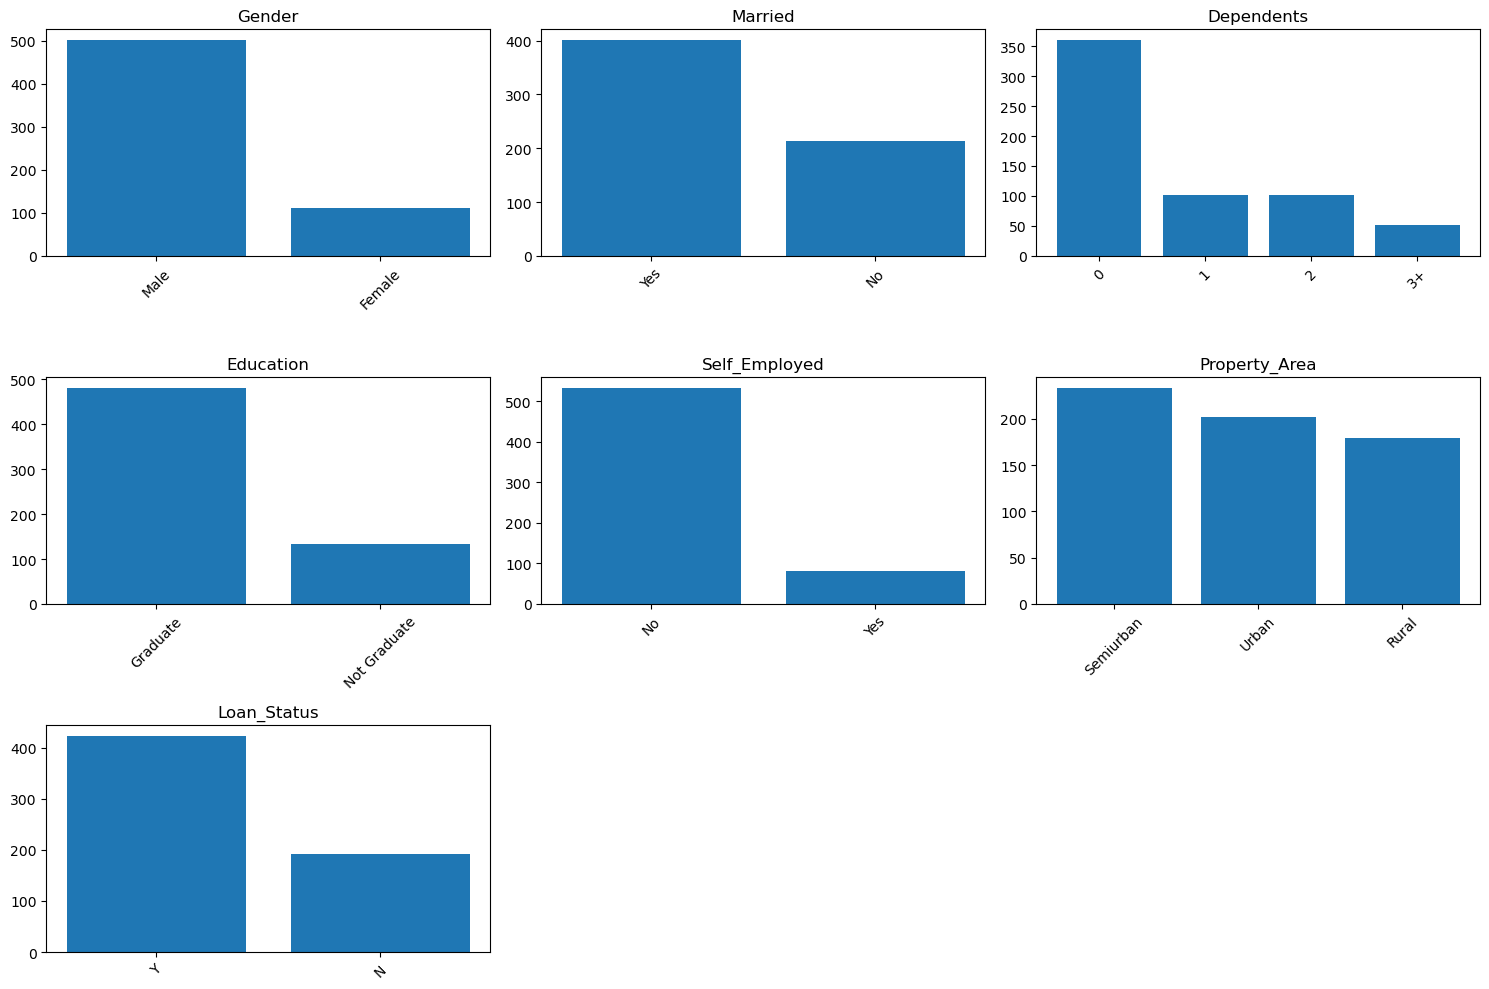

In [48]:
import matplotlib.pyplot as plt 
cat_cols = loan_data.select_dtypes(include="object").columns 
plt.figure(figsize=(15, 10)) 
for i, col in enumerate(cat_cols):    
    keys = loan_data[col].value_counts().keys()    
    values = loan_data[col].value_counts().values   
    plt.subplot(3, 3, i + 1)   
    plt.bar(keys, values)   
    plt.title(col)   
    plt.xticks(rotation=45) 
    
plt.tight_layout()
plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

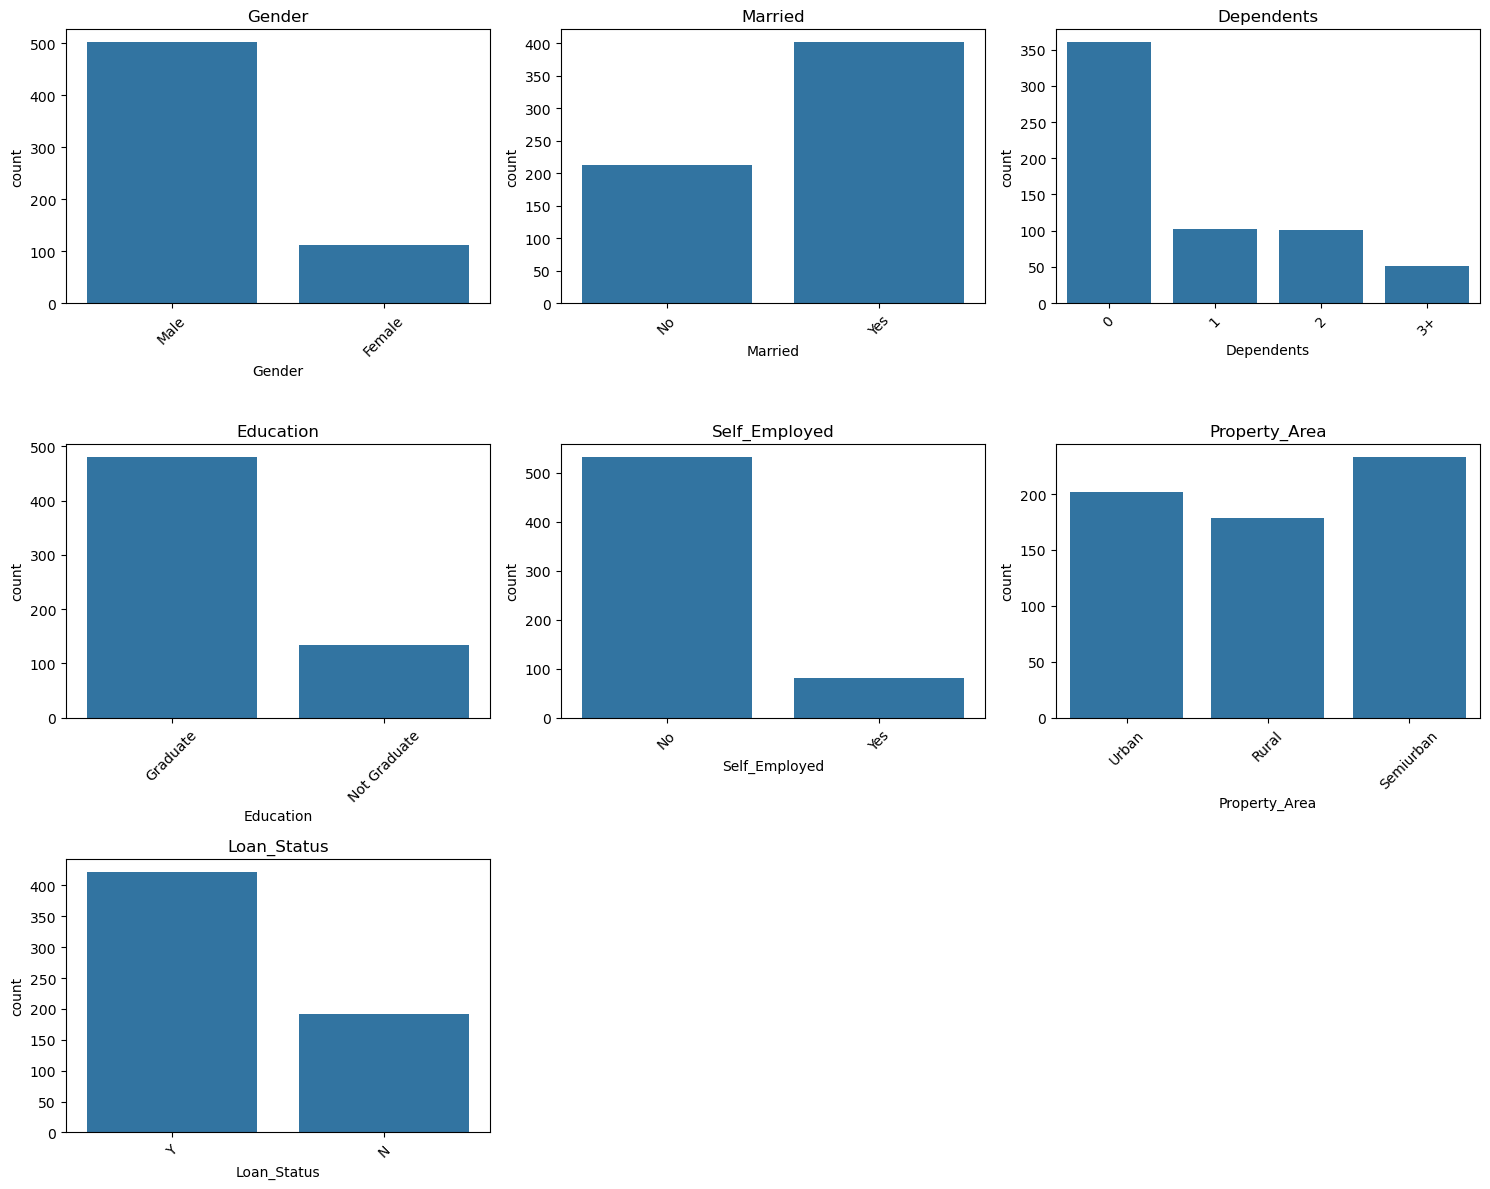

In [49]:
# count plot
cat_cols = loan_data.select_dtypes(include="object").columns 
plt.figure(figsize=(15, 12))
for i, col in enumerate(cat_cols):   
    plt.subplot(3, 3, i + 1)    
    sns.countplot(x=col, data=loan_data)  
    plt.title(col)    
    plt.xticks(rotation=45)
    
plt.tight_layout()
plt.show

In [ ]:
# pie chart

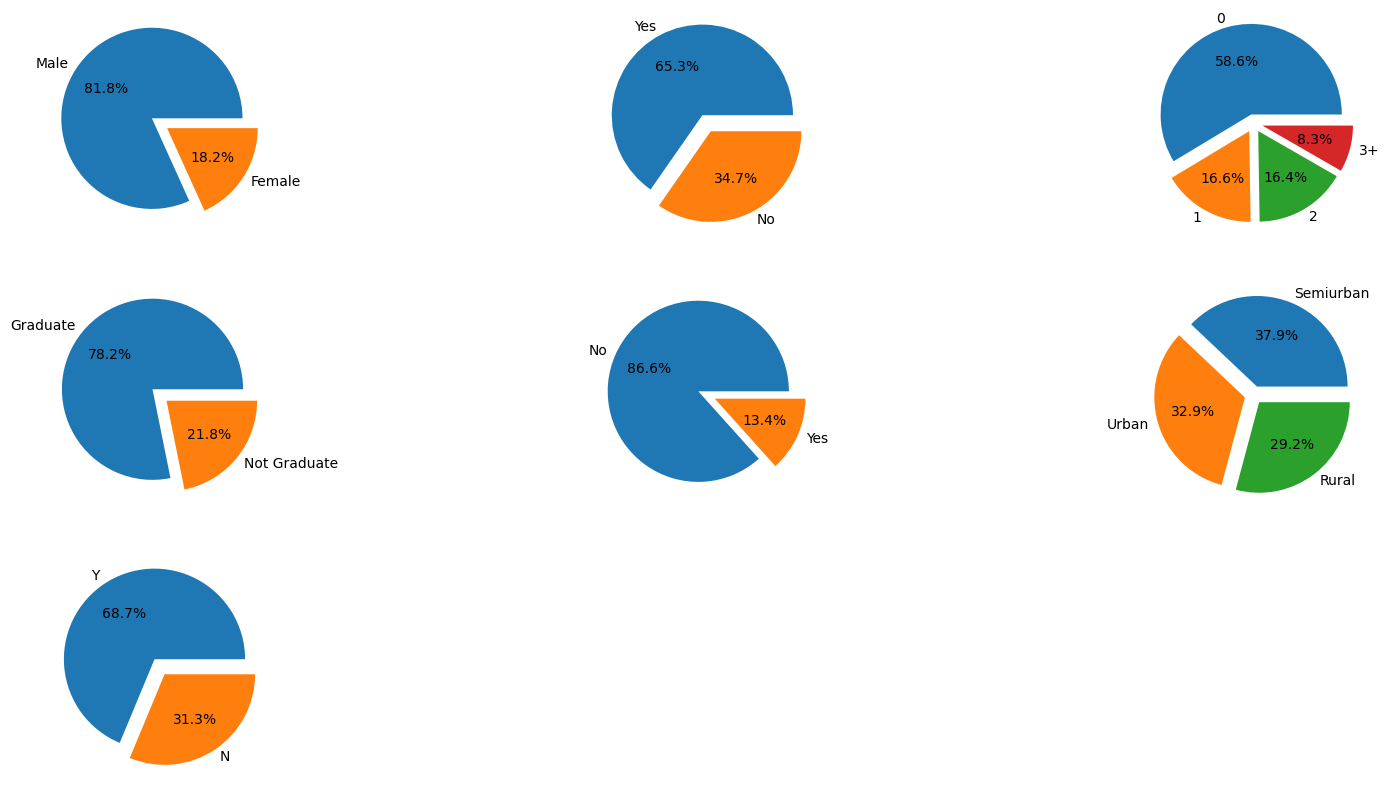

In [52]:
import matplotlib.pyplot as plt
col=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
plt.figure(figsize=(20, 10)) 
for i in range(len(col)): 
    plt.subplot(3,3,i+1)  
    c=col[i]  
    keys=loan_data[c].value_counts().keys()   
    values=loan_data[c].value_counts().values   
    plt.pie(values, labels=keys, explode=[0.1]*len(keys),  
            autopct="%1.1f%%")

In [ ]:
# step-6: numerical data analysis

In [57]:
num

Index(['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',
       'Loan_Amount_Term', 'Credit_History'],
      dtype='object')

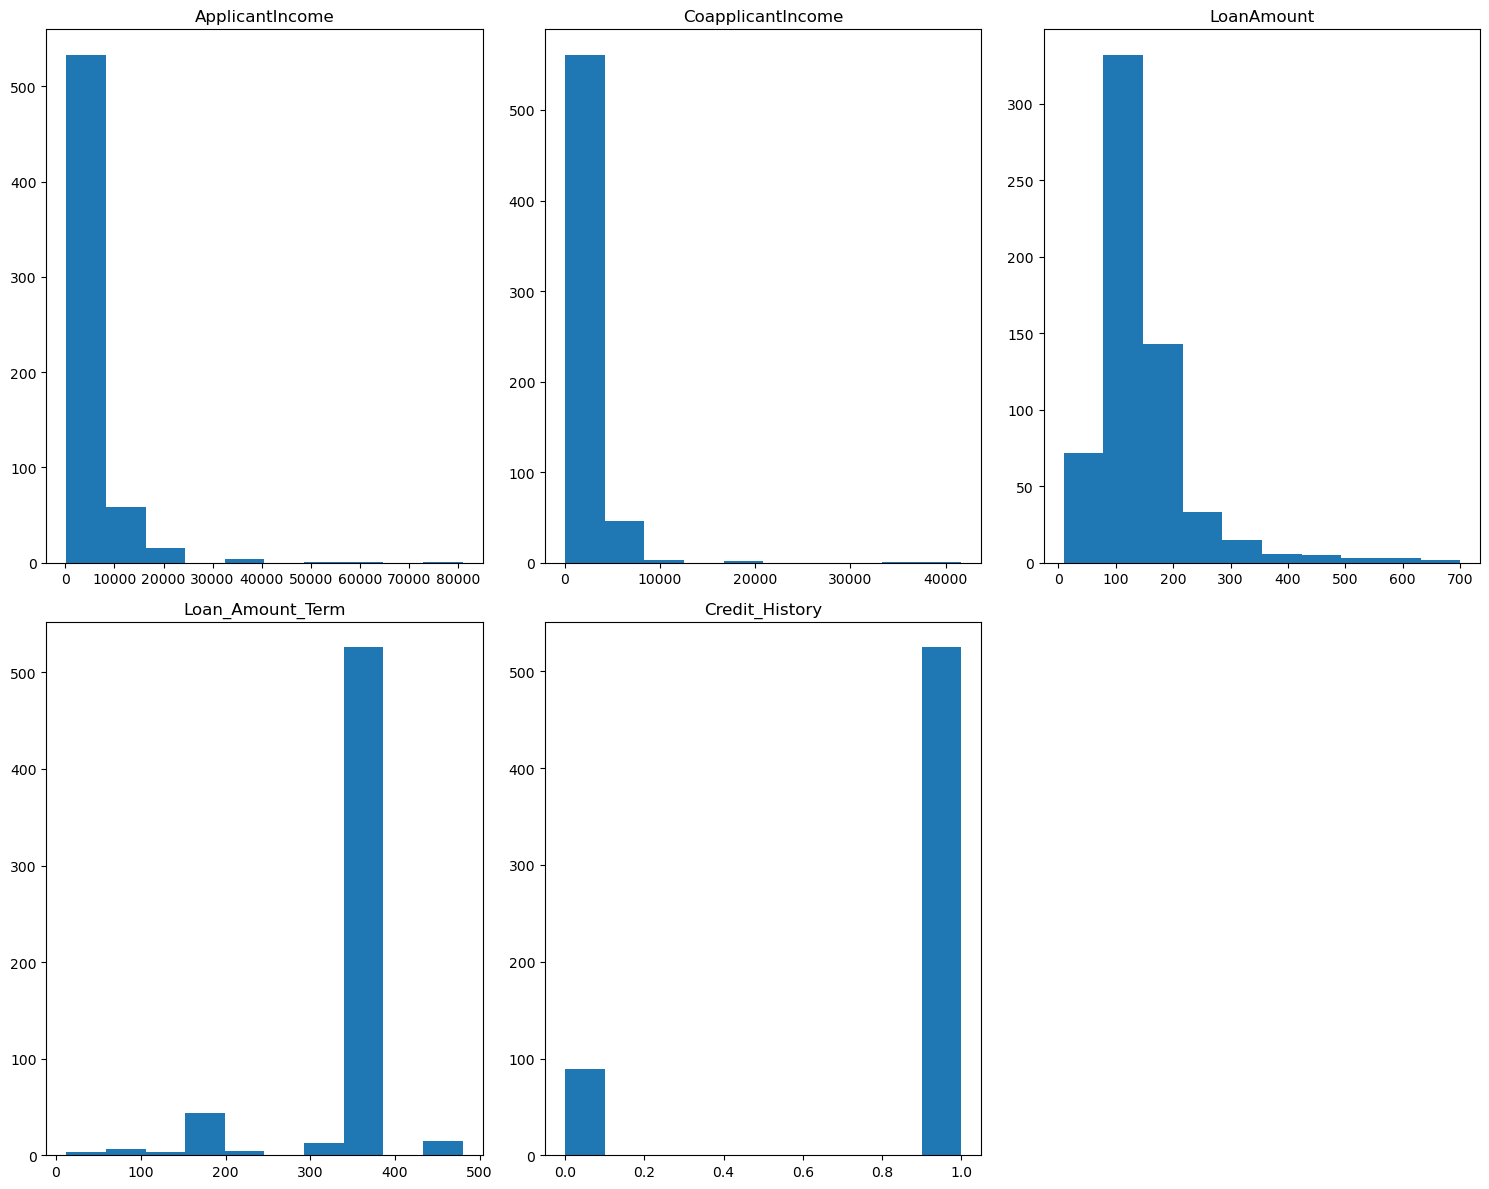

In [60]:
 # Histogram 
col=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History'] 
plt.figure(figsize=(15, 12))
for i in range(len(col)): 
    c = col[i]
    plt.subplot(2, 3, i + 1)
    plt.hist(loan_data[c])
    plt.title(c)
    
plt.tight_layout() 
plt.show()

In [ ]:
# data skew ness

In [61]:
# describe
loan_data.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,614.000000,614.000000,614.000000
mean,5403.459283,1621.245798,145.752443,342.410423,0.855049
std,6109.041673,2926.248369,84.107233,64.428629,0.352339
min,150.000000,0.000000,9.000000,12.000000,0.000000
25%,2877.500000,0.000000,100.250000,360.000000,1.000000
50%,3812.500000,1188.500000,128.000000,360.000000,1.000000
75%,5795.000000,2297.250000,164.750000,360.000000,1.000000
max,81000.000000,41667.000000,700.000000,480.000000,1.000000


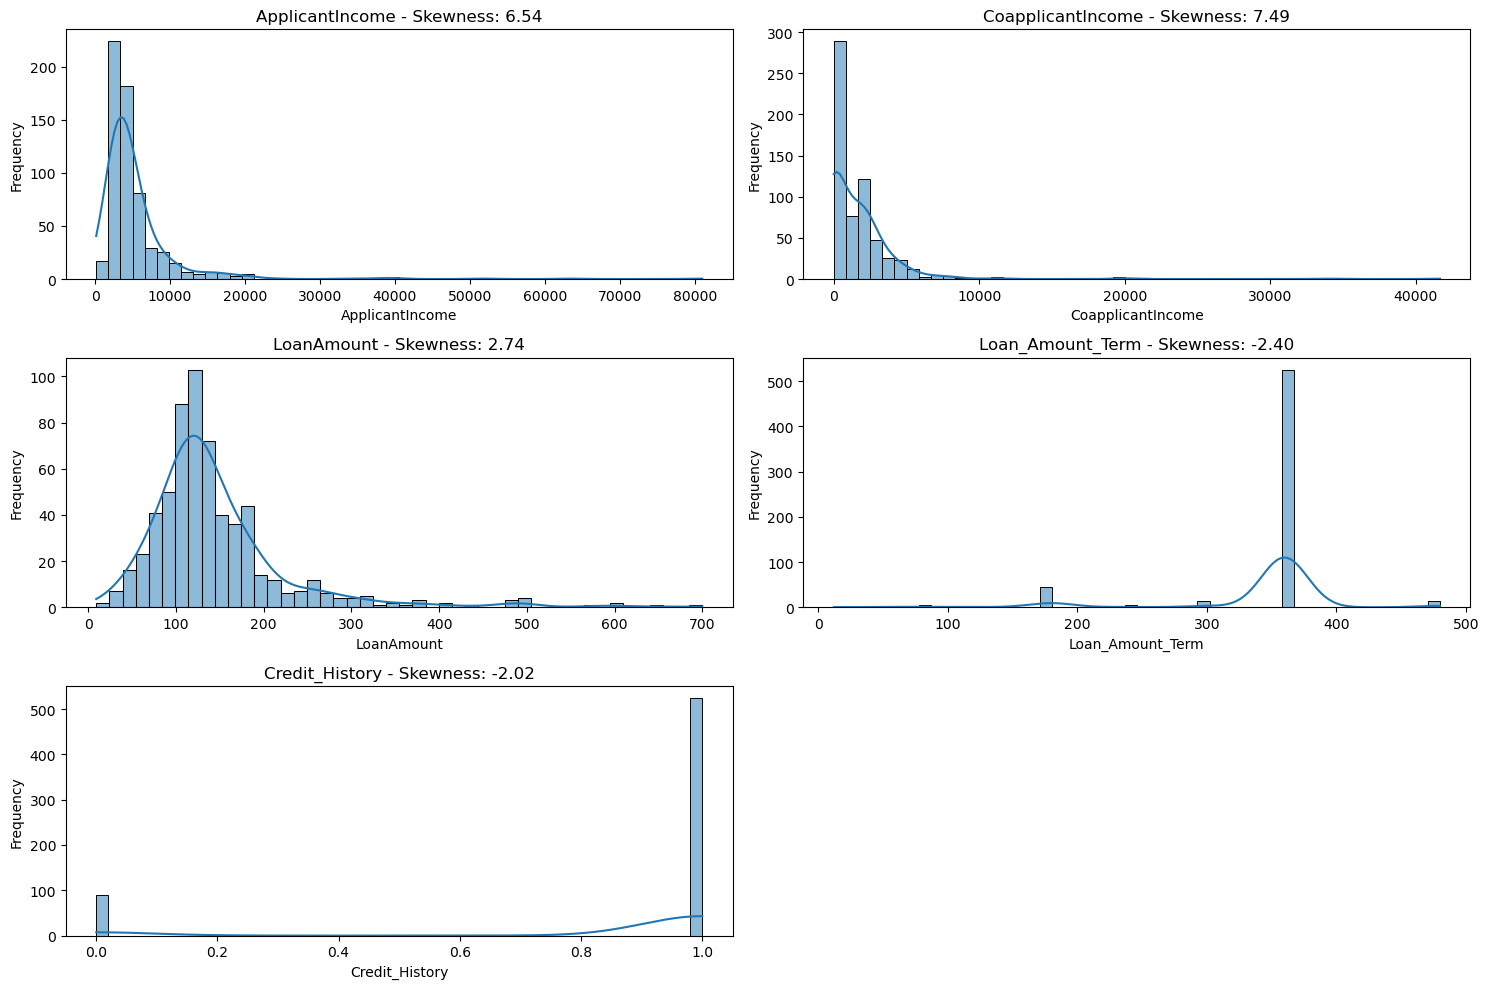

In [64]:
# graphical representation of skewness 
import matplotlib.pyplot as plt
import seaborn as sns
num_cols = [ 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount',  'Loan_Amount_Term', 'Credit_History'] 
plt.figure(figsize=(15, 10)) 
for i, col in enumerate(num_cols): 
    plt.subplot(3, 2, i + 1) 
    sns.histplot(loan_data[col], kde=True) 
    plt.title(f"{col} - Skewness: {loan_data[col].skew():.2f}")
    plt.xlabel(col) 
    plt.ylabel("Frequency")
    
plt.tight_layout() 
plt.show()

In [66]:
# Step-7: Box plot creation 
col= ['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term'] 
for c in col:
    q1=round(np.percentile(loan_data[c],25),2) 
    q2=round(np.percentile(loan_data[c],50),2)
    q3=round(np.percentile(loan_data[c],75),2)
    iqr=q3-q1 
    lb=q1-1.5*iqr 
    ub=q3+1.5*iqr 
    loan_data[c]=loan_data[c].clip(lb,ub) 
loan_data

,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,0,Graduate,No,5849.0,0.0,128.0,360.0,1.0,Urban,Y
1,Male,Yes,1,Graduate,No,4583.0,1508.0,128.0,360.0,1.0,Rural,N
2,Male,Yes,0,Graduate,Yes,3000.0,0.0,66.0,360.0,1.0,Urban,Y
3,Male,Yes,0,Not Graduate,No,2583.0,2358.0,120.0,360.0,1.0,Urban,Y
4,Male,No,0,Graduate,No,6000.0,0.0,141.0,360.0,1.0,Urban,Y
...,...,...,...,...,...,...,...,...,...,...,...,...
609,Female,No,0,Graduate,No,2900.0,0.0,71.0,360.0,1.0,Rural,Y
610,Male,Yes,3+,Graduate,No,4106.0,0.0,40.0,360.0,1.0,Rural,Y
611,Male,Yes,1,Graduate,No,8072.0,240.0,253.0,360.0,1.0,Urban,Y
612,Male,Yes,2,Graduate,No,7583.0,0.0,187.0,360.0,1.0,Urban,Y


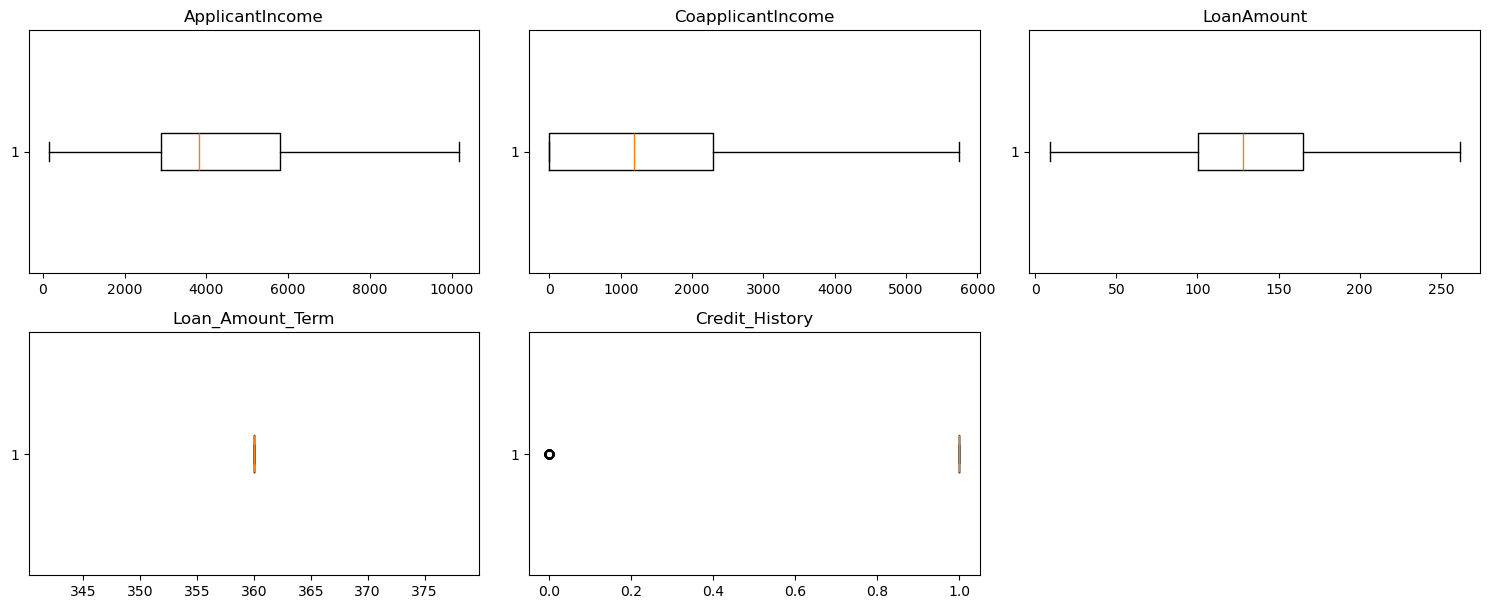

In [68]:
# checking outliers 
col=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term',
     'Credit_History']
plt.figure(figsize=(15, 12))
for i in range(len(col)):   
    c = col[i]   
    plt.subplot(4, 3, i + 1)   
    plt.boxplot(loan_data[c],vert=False)   
    plt.title(c) 
plt.tight_layout()
plt.viridis() 
plt.show()

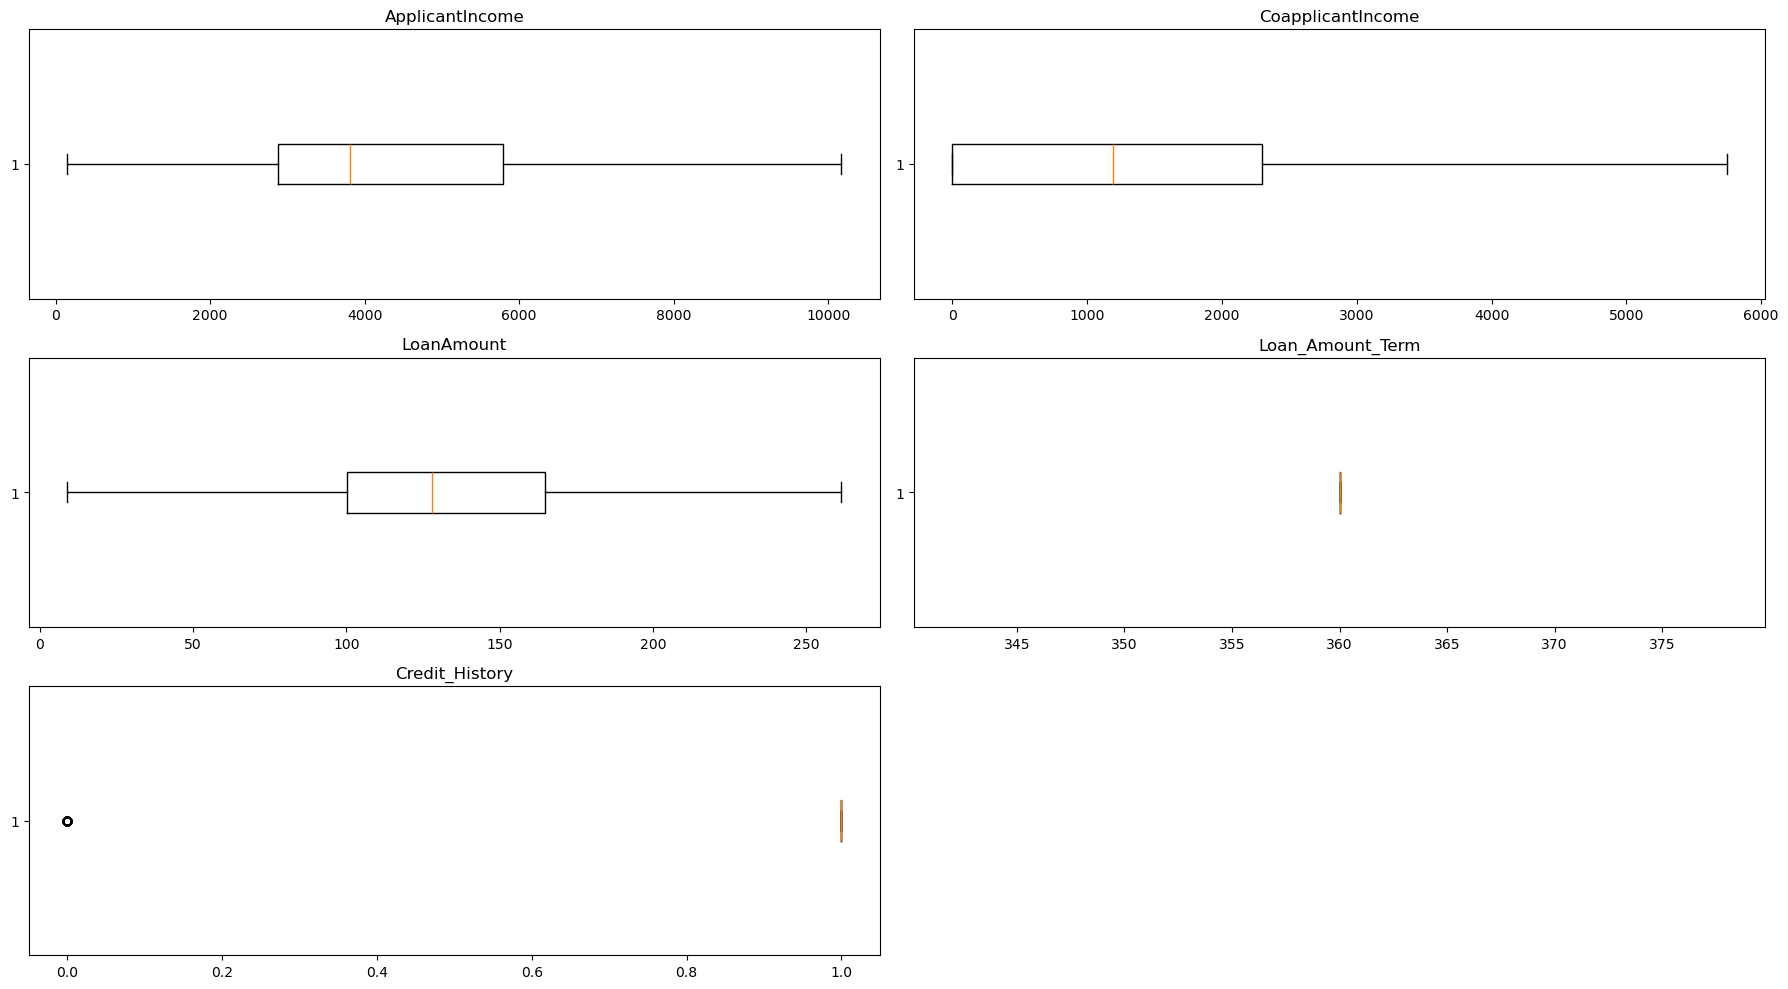

In [70]:
# clear outliers
col=['ApplicantIncome','CoapplicantIncome','LoanAmount','Loan_Amount_Term','Credit_History']
plt.figure(figsize=(18, 10))
for i in range(len(col)): 
    plt.subplot(3,2 , i + 1)  
    plt.boxplot(loan_data[col[i]],vert=False)
     
    plt.title(col[i])
    
plt.tight_layout()
plt.show()

In [71]:
col1=['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Loan_Status']
for c in col1: 
    print(c)
    print(loan_data[c].unique()) 
    print()

Gender
['Male' 'Female']

Married
['No' 'Yes']

Dependents
['0' '1' '2' '3+']

Education
['Graduate' 'Not Graduate']

Self_Employed
['No' 'Yes']

Property_Area
['Urban' 'Rural' 'Semiurban']

Loan_Status
['Y' 'N']



In [72]:
# Step-9: Encoding methods
# map 
d={'Female':0,'Male':1} 
loan_data["Gender"]=loan_data["Gender"].map(d) 
loan_data["Gender"]

0      1
1      1
2      1
3      1
4      1
      ..
609    0
610    1
611    1
612    1
613    0
Name: Gender, Length: 614, dtype: int64

In [73]:
d1={'No':0,'Yes':1} 
loan_data["Married"]=loan_data["Married"].map(d1) 
loan_data["Married"]

0      0
1      1
2      1
3      1
4      0
      ..
609    0
610    1
611    1
612    1
613    0
Name: Married, Length: 614, dtype: int64

In [74]:
d={'Graduate':0, 'Not Graduate':1}
loan_data["Education"]=loan_data["Education"].map(d) 
loan_data["Education"]

0      0
1      0
2      0
3      1
4      0
      ..
609    0
610    0
611    0
612    0
613    0
Name: Education, Length: 614, dtype: int64

In [75]:
d={'Urban':0 ,'Rural':1 ,'Semiurban':2}
loan_data["Property_Area"]=loan_data["Property_Area"].map(d) 
loan_data["Property_Area"]

0      0
1      1
2      0
3      0
4      0
      ..
609    1
610    1
611    0
612    0
613    2
Name: Property_Area, Length: 614, dtype: int64

In [76]:
d={'Y':0 ,'N':1}
loan_data["Loan_Status"]=loan_data["Loan_Status"].map(d) 
loan_data["Loan_Status"]

0      0
1      1
2      0
3      0
4      0
      ..
609    0
610    0
611    0
612    0
613    1
Name: Loan_Status, Length: 614, dtype: int64

In [77]:
#  np.where 
loan_data["Loan_Status"]=np.where(loan_data["Loan_Status"]=="Y",1,0) 
loan_data["Loan_Status"]

0      0
1      0
2      0
3      0
4      0
      ..
609    0
610    0
611    0
612    0
613    0
Name: Loan_Status, Length: 614, dtype: int64

In [78]:
# LabelEncoder
from sklearn.preprocessing import LabelEncoder 
le = LabelEncoder()
loan_data["Gender"] = le.fit_transform(loan_data["Gender"]) 
loan_data["Gender"]

0      1
1      1
2      1
3      1
4      1
      ..
609    0
610    1
611    1
612    1
613    0
Name: Gender, Length: 614, dtype: int64